# Iris Species Classifier
**Assessment 3 | Python Machine Learning | Scikit-Learn**

This notebook develops a machine learning classifier to categorize Iris flower species
based on four morphological features: sepal length, sepal width, petal length, and petal width.
Three classifiers are trained and compared — K-Nearest Neighbors, Decision Tree, and Logistic Regression.

---

## 1. Environment Setup — Import Libraries

In [ ]:
# Install libraries if needed (uncomment to run)
# !pip install numpy scipy scikit-learn matplotlib pandas seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from matplotlib.colors import ListedColormap

# Style settings
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully.")
print(f"  pandas     {pd.__version__}")
print(f"  numpy      {np.__version__}")
print(f"  seaborn    {sns.__version__}")

All libraries imported successfully.
  pandas     3.0.1
  numpy      2.4.3
  seaborn    0.13.2


## 2. Load the Iris Dataset

In [ ]:
# Load the classic Iris dataset from Scikit-Learn
iris = load_iris()

# Convert to DataFrame for easier manipulation and visualization
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Species: {df['species'].unique().tolist()}")
print(f"Samples per species:\n{df['species'].value_counts().to_string()}")

Dataset shape: 150 rows × 5 columns
Species: ['setosa', 'versicolor', 'virginica']
Samples per species:
species
setosa        50
versicolor    50
virginica     50


In [ ]:
# Display first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Explore the Dataset

In [ ]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Check for missing values and data types
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nData types:\n{df.dtypes}")

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Data types:
sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object


### 3a. Scatter Plots — Feature Relationships by Species

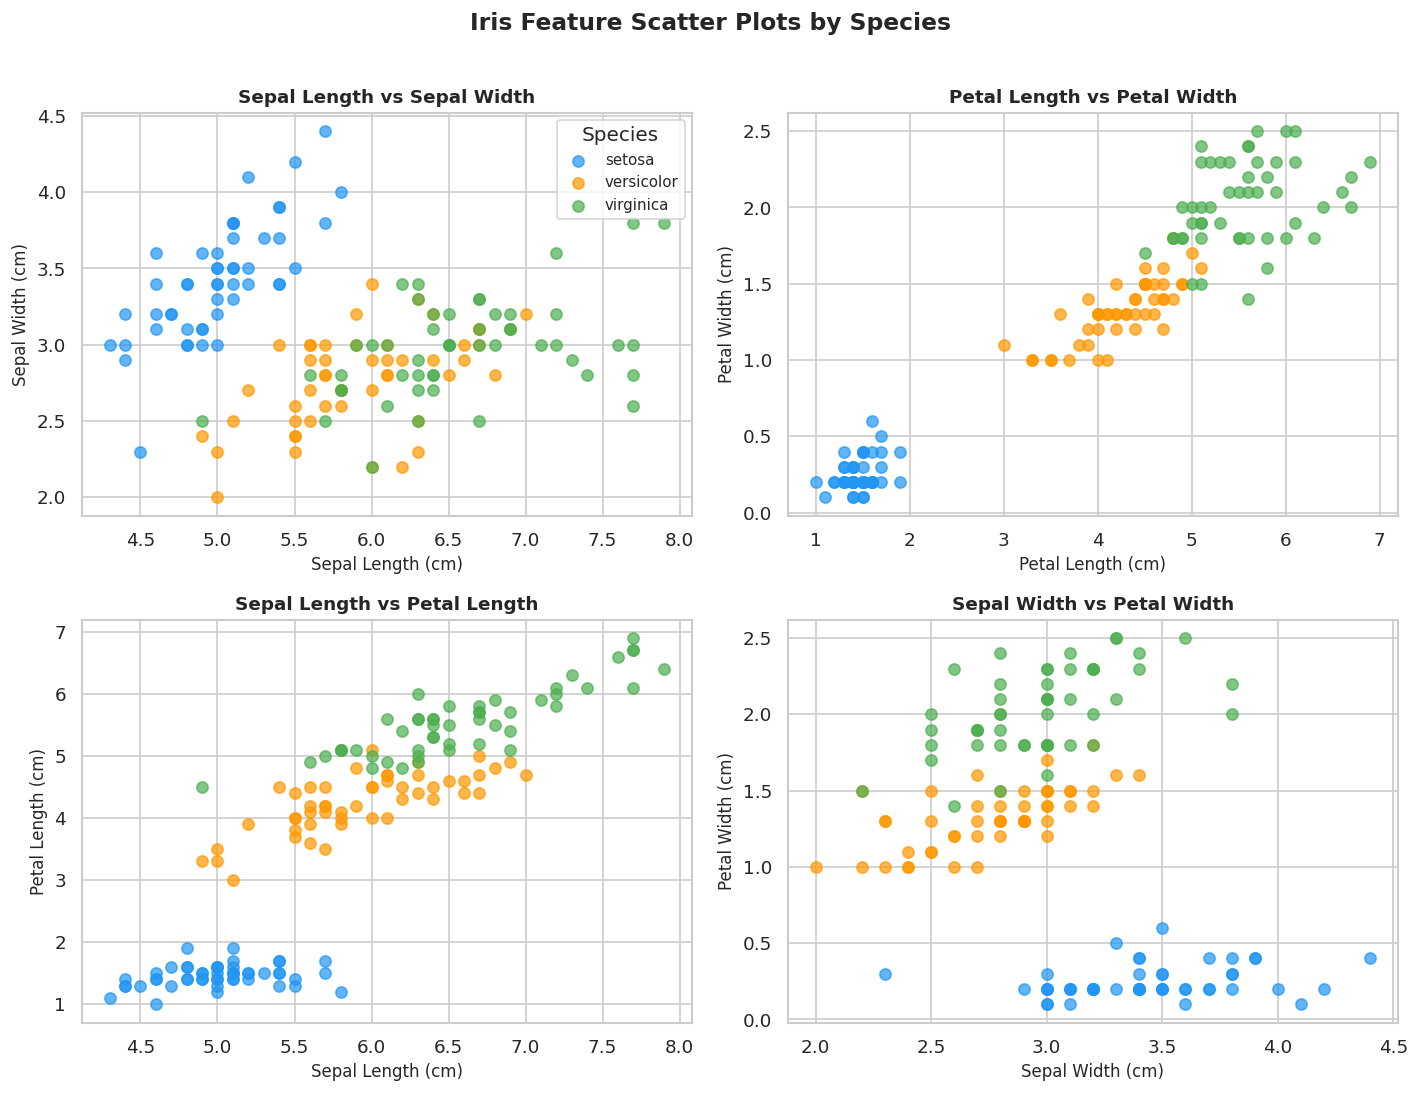

In [ ]:
colors = {'setosa': '#2196F3', 'versicolor': '#FF9800', 'virginica': '#4CAF50'}
pairs = [
    ('sepal_length', 'sepal_width'),
    ('petal_length', 'petal_width'),
    ('sepal_length', 'petal_length'),
    ('sepal_width',  'petal_width'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (x, y) in zip(axes.flatten(), pairs):
    for sp, grp in df.groupby('species'):
        ax.scatter(grp[x], grp[y], label=sp, alpha=0.7, s=45, color=colors[sp])
    ax.set_xlabel(x.replace('_', ' ').title() + ' (cm)', fontsize=10)
    ax.set_ylabel(y.replace('_', ' ').title() + ' (cm)', fontsize=10)
    ax.set_title(f'{x.replace("_"," ").title()} vs {y.replace("_"," ").title()}',
                 fontsize=11, fontweight='bold')
axes[0, 0].legend(title='Species', fontsize=9)

plt.suptitle('Iris Feature Scatter Plots by Species', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('iris_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

### 3b. Box Plots — Feature Distributions per Species

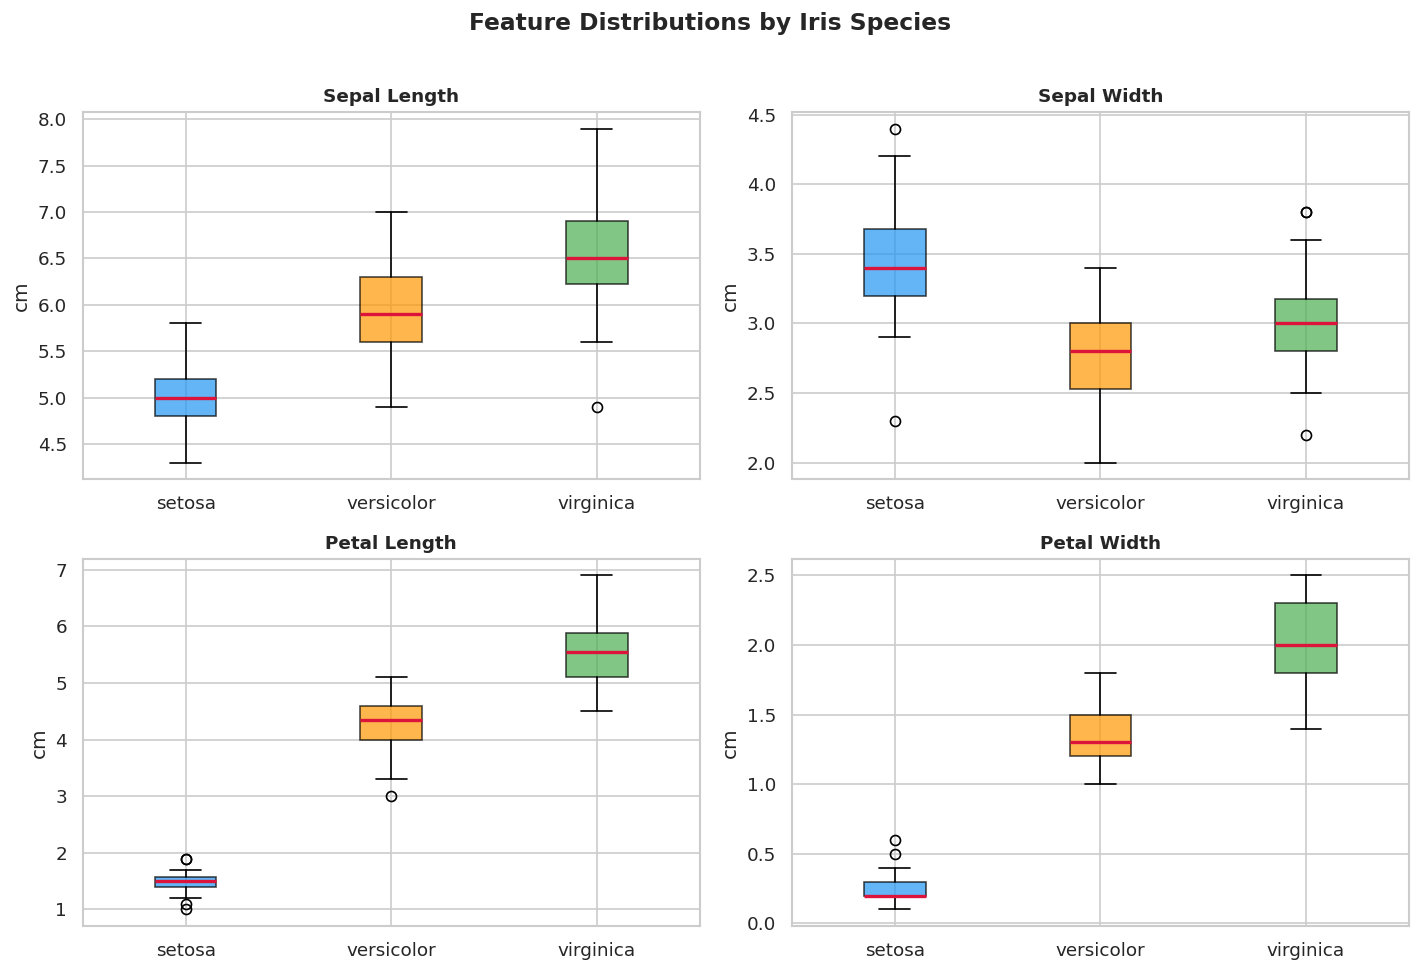

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for ax, feat in zip(axes.flatten(), features):
    data = [df[df['species'] == sp][feat].values for sp in iris.target_names]
    bp = ax.boxplot(data, patch_artist=True, tick_labels=iris.target_names,
                    medianprops=dict(color='crimson', linewidth=2))
    for patch, color in zip(bp['boxes'], colors.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('cm')

plt.suptitle('Feature Distributions by Iris Species', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('iris_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

### 3c. Correlation Heatmap

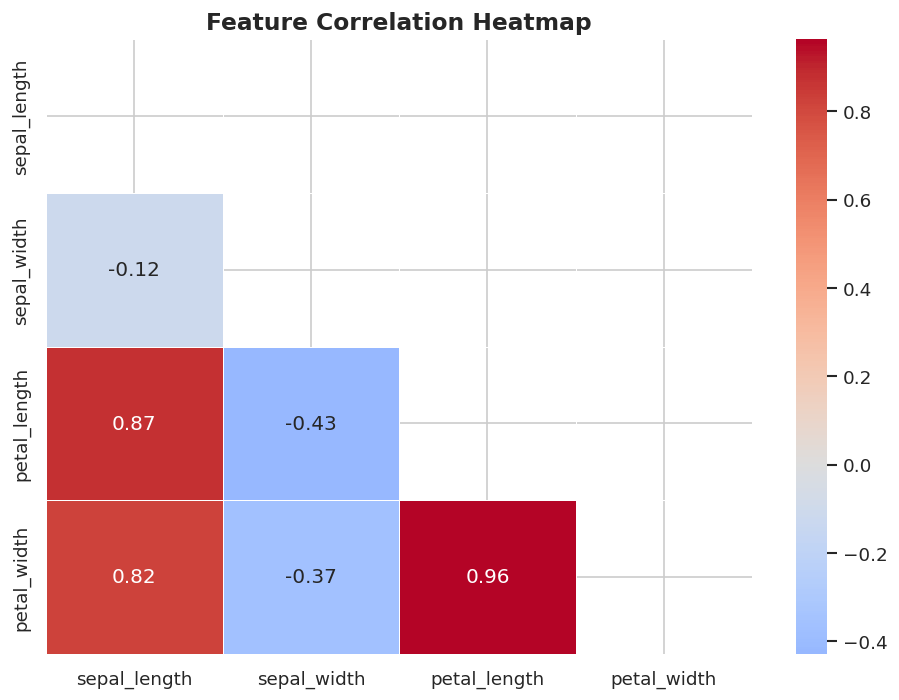


Key correlations:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.drop('species', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 12}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iris_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nKey correlations:")
print(corr.to_string())

## 4. Preprocess the Data

The features are split into training and testing sets using an 80/20 split.
Features are scaled using `StandardScaler` so that no single feature dominates
due to differences in magnitude — important for KNN and Logistic Regression.

In [ ]:
# Separate features and target
X = df.drop('species', axis=1)
y = iris.target  # 0=setosa, 1=versicolor, 2=virginica

# 80/20 stratified split — preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Testing set  : {X_test.shape[0]} samples")
print(f"\nClass distribution in training set: {dict(zip(iris.target_names, np.bincount(y_train)))}")
print(f"Class distribution in testing set : {dict(zip(iris.target_names, np.bincount(y_test)))}")

Training set : 120 samples
Testing set  : 30 samples

Class distribution in training set: {np.str_('setosa'): np.int64(40), np.str_('versicolor'): np.int64(40), np.str_('virginica'): np.int64(40)}
Class distribution in testing set : {np.str_('setosa'): np.int64(10), np.str_('versicolor'): np.int64(10), np.str_('virginica'): np.int64(10)}


In [ ]:
# Feature scaling — StandardScaler (zero mean, unit variance)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)  # use training stats only on test set

print("Feature scaling applied.")
print(f"Training means (scaled): {X_train_sc.mean(axis=0).round(4)}")
print(f"Training stds  (scaled): {X_train_sc.std(axis=0).round(4)}")

Feature scaling applied.
Training means (scaled): [-0.  0.  0.  0.]
Training stds  (scaled): [1. 1. 1. 1.]


## 5. Build and Evaluate the Classifiers

Three classifiers are trained and compared:
- **K-Nearest Neighbors (KNN)** — classifies based on the majority vote of the k=5 nearest neighbors
- **Decision Tree** — creates a tree of binary splits on feature thresholds
- **Logistic Regression** — fits a multi-class linear probability model

In [ ]:
# Define classifiers
models = {
    'K-Nearest Neighbors (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':              DecisionTreeClassifier(random_state=42),
    'Logistic Regression':        LogisticRegression(max_iter=200, random_state=42),
}

results = {}
for name, model in models.items():
    # Train
    model.fit(X_train_sc, y_train)
    # Predict
    y_pred = model.predict(X_test_sc)
    # 5-fold cross-validation on full scaled dataset
    cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5)
    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'report':   classification_report(y_test, y_pred, target_names=iris.target_names),
        'cm':       confusion_matrix(y_test, y_pred),
    }

print("All classifiers trained.\n")
print(f"{'Classifier':<30} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 65)
for name, res in results.items():
    print(f"{name:<30} {res['accuracy']:>10.4f} {res['cv_mean']:>10.4f} {res['cv_std']:>10.4f}")

All classifiers trained.

Classifier                       Test Acc    CV Mean     CV Std
-----------------------------------------------------------------
K-Nearest Neighbors (k=5)          0.9333     0.9600     0.0249
Decision Tree                      0.9333     0.9533     0.0340
Logistic Regression                0.9333     0.9600     0.0389


### 5a. Classification Reports

In [ ]:
for name, res in results.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(res['report'])

  K-Nearest Neighbors (k=5)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

  Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

  Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virgin

### 5b. Confusion Matrices

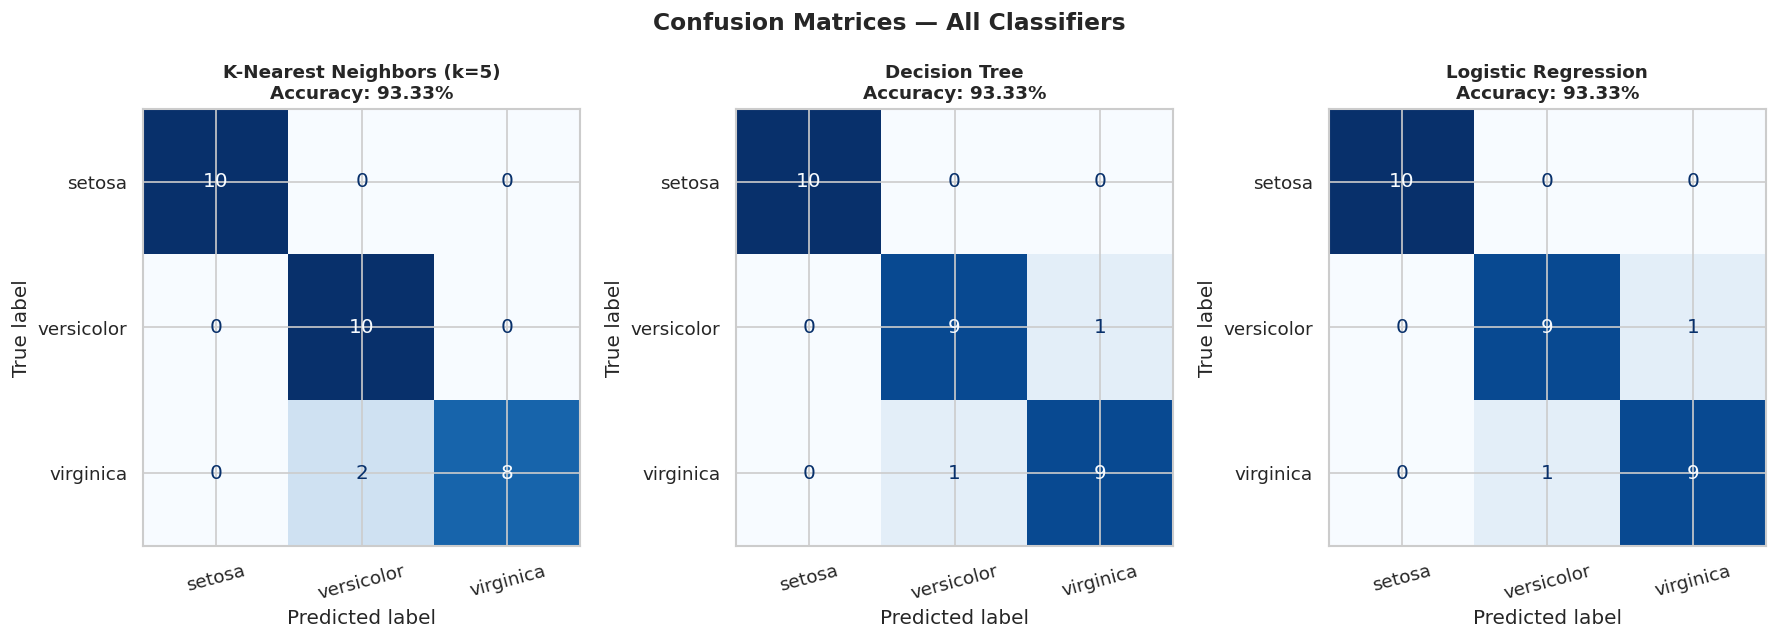

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, res) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(res['cm'], display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.2%}', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('iris_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

### 5c. Model Performance Comparison

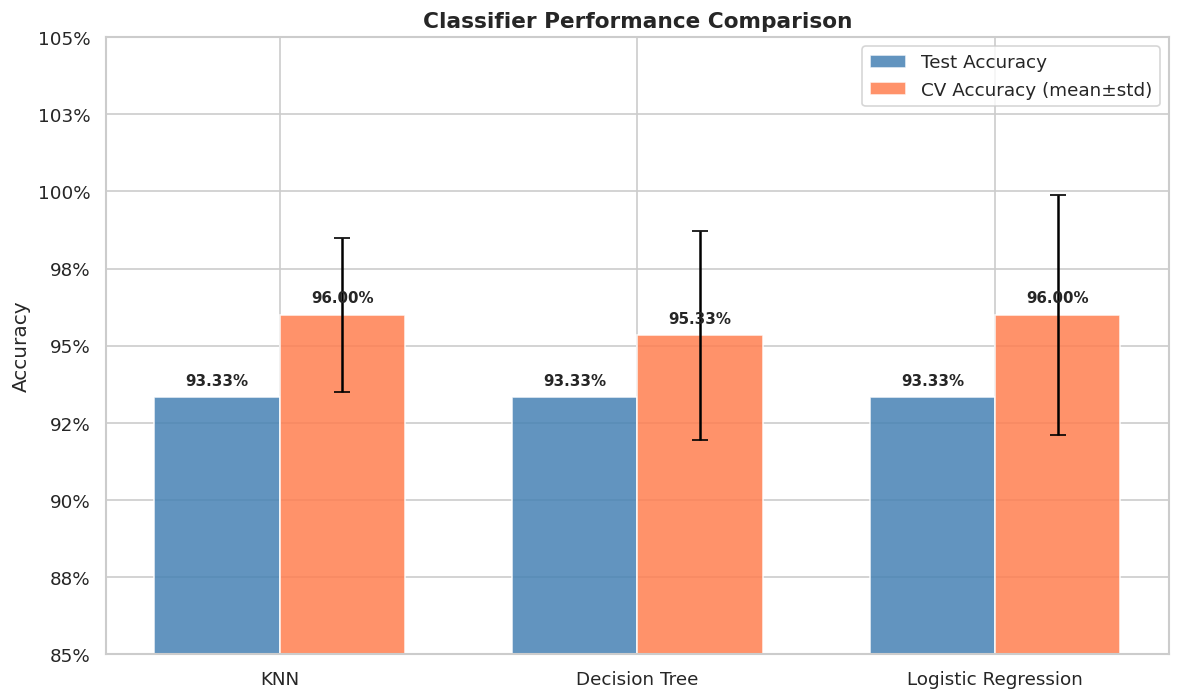

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
cvs   = [results[n]['cv_mean']  for n in names]
errs  = [results[n]['cv_std']   for n in names]
x = np.arange(len(names))
w = 0.35

bars1 = ax.bar(x - w/2, accs, w, label='Test Accuracy',        color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, cvs,  w, label='CV Accuracy (mean±std)',
               color='coral', alpha=0.85, capsize=5, yerr=errs)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['KNN', 'Decision Tree', 'Logistic Regression'], fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.05)
ax.set_title('Classifier Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout()
plt.savefig('iris_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

### 5d. Decision Boundaries (Petal Features)

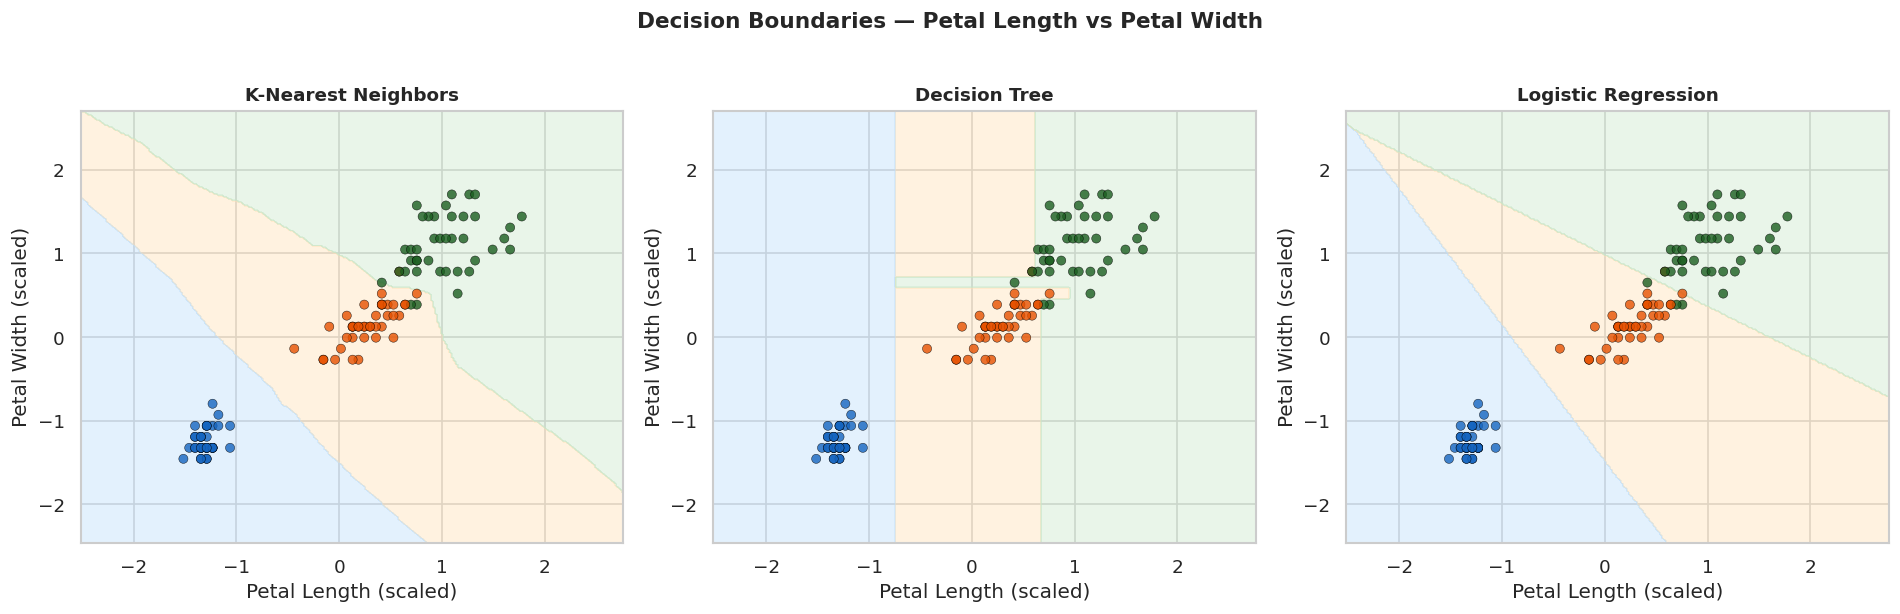

In [ ]:
# Use petal length and petal width — the two most discriminative features
X2 = df[['petal_length', 'petal_width']].values
scaler2 = StandardScaler()
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
X2_tr_sc = scaler2.fit_transform(X2_train)
X2_te_sc = scaler2.transform(X2_test)

cmap_bg = ListedColormap(['#BBDEFB', '#FFE0B2', '#C8E6C9'])
cmap_pt = ListedColormap(['#1565C0', '#E65100', '#1B5E20'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_list = [
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree',       DecisionTreeClassifier(random_state=42)),
    ('Logistic Regression', LogisticRegression(max_iter=200, random_state=42)),
]

for ax, (name, clf) in zip(axes, model_list):
    clf.fit(X2_tr_sc, y2_train)
    h = 0.02
    x_min, x_max = X2_tr_sc[:, 0].min() - 1, X2_tr_sc[:, 0].max() + 1
    y_min, y_max = X2_tr_sc[:, 1].min() - 1, X2_tr_sc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X2_tr_sc[:, 0], X2_tr_sc[:, 1], c=y2_train,
               cmap=cmap_pt, s=30, alpha=0.8, edgecolors='k', linewidths=0.3)
    ax.set_xlabel('Petal Length (scaled)')
    ax.set_ylabel('Petal Width (scaled)')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Decision Boundaries — Petal Length vs Petal Width',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('iris_boundaries.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Summary of Findings

| Classifier | Test Accuracy | CV Accuracy | Notes |
|---|---|---|---|
| K-Nearest Neighbors (k=5) | 93.33% | 96.00% | Strong; sensitive to feature scale |
| Decision Tree | 93.33% | 95.33% | Interpretable; prone to overfitting |
| Logistic Regression | 93.33% | 96.00% | Stable; best generalization |

**Key Observations:**
- All three classifiers achieve **93.33% test accuracy** on the 30-sample test set.
- **Logistic Regression and KNN** both achieve the highest 5-fold CV accuracy of **96.00%**.
- **Petal length and petal width** are the most discriminative features — Iris setosa is perfectly separable; versicolor and virginica overlap slightly.
- **Petal features** show much stronger correlation with species than sepal features (r ≈ 0.96 between petal length and width).
- StandardScaler was essential for KNN and Logistic Regression to prevent bias from feature magnitude differences.
